In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import confusion_matrix, classification_report
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA 

In [3]:
# Section 1: Load data
df = pd.read_csv("/Users/noahwestheimer/Documents/DTU/2. semester/Sommer kurser/02445 project in statistical evaluation of aI/Individual Assignment /assignment (1)/task_2/HR_data.csv")
# only use heart rate features 
X = df[['HR_Mean', 'HR_Median', 'HR_std', 'HR_Min', 'HR_Max']].values

# define taget atribbute 
frustration = df["Frustrated"].values
y = np.zeros_like(frustration, dtype=int)

# define class values
y[frustration <= 2] = 0
y[(frustration > 2) & (frustration <= 4)] = 1
y[(frustration > 4) & (frustration <= 6)] = 2
y[(frustration > 6) & (frustration <= 8)] = 3
y[frustration > 8] = 4

# define subject ids 
subject_ids = df["Individual"].values

# print shapes and count number of observations within classes
print(f"X: {X.shape}, y: {y.shape}")
print(f"Classes: {np.bincount(y)}")

X: (168, 5), y: (168,)
Classes: [105  39  19   5]


Just typing `X` on its own makes the notebook display the array, so we can quickly look at the raw feature values before we standardise them.

In [ ]:
X

# show X 

array([[ 77.96518644,  78.        ,   3.34529031,  73.23      ,
         83.37      ],
       [ 70.98109677,  70.57      ,   2.517879  ,  67.12      ,
         78.22      ],
       [ 73.37195946,  73.36      ,   3.25956868,  67.88      ,
         80.22      ],
       [ 78.91682243,  77.88      ,   4.05459491,  72.32      ,
         84.92      ],
       [ 77.32222581,  74.55      ,   6.04760322,  70.52      ,
         90.15      ],
       [ 74.37206081,  74.05      ,   2.06185834,  71.27      ,
         79.22      ],
       [ 77.25340067,  77.75      ,   3.20475484,  72.43      ,
         82.9       ],
       [ 72.69990066,  72.75      ,   2.69268462,  66.25      ,
         77.12      ],
       [ 73.89095975,  74.37      ,   3.47980831,  67.48      ,
         80.85      ],
       [ 72.62548276,  72.275     ,   3.6875375 ,  67.55      ,
         81.78      ],
       [ 74.22255255,  75.5       ,   4.74187159,  63.92      ,
         80.85      ],
       [ 77.78071101,  77.93      ,   1.494

In [5]:


# standadize data and center for explatory plots to estimate the number of principle components needed :
X_mean_orig = np.mean(X, axis=0)
X_std_orig = np.std(X, axis=0)
X_std = (X - X_mean_orig) / X_std_orig

print("Mean after standardization:", np.round(np.mean(X_std, axis=0), 3))
print("Std after standardization: ", np.round(np.std(X_std, axis=0), 3))
# raw data is still saved this is only for estimation of explained variance per principle component 

Mean after standardization: [ 0. -0. -0. -0. -0.]
Std after standardization:  [1. 1. 1. 1. 1.]


In [ ]:
#  PCA and variance explained (exploratory: fit on all standardized data)
def compute_pca(X, n_components=2):
    X_mean = np.mean(X, axis=0)
    X_centered = X - X_mean
    U, s, Vt = np.linalg.svd(X_centered)
    V = Vt.T
    V_k = V[:, :n_components]
    return V_k, X_mean

V_k, X_mean = compute_pca(X_std, n_components=2)
X_pca = (X_std - X_mean) @ V_k

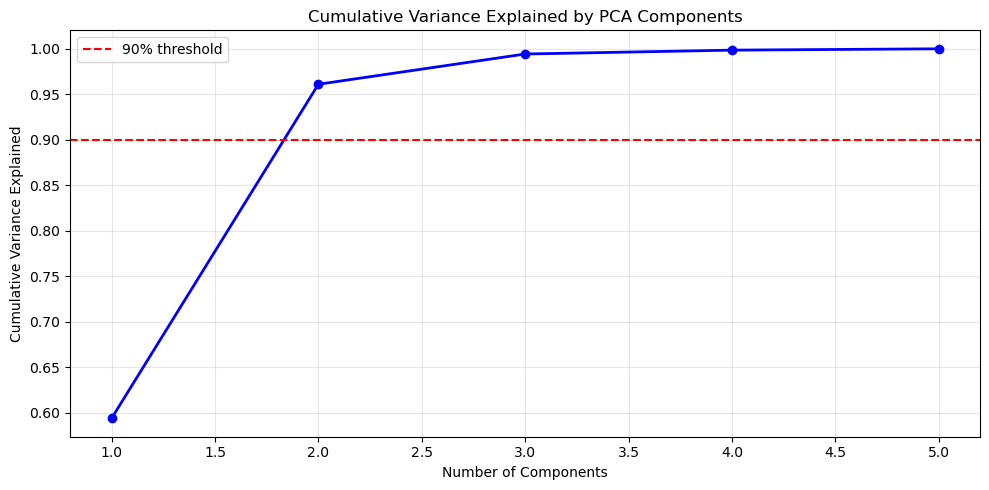

Components needed for 95% variance: 2


In [7]:
# Compute PCA variance (on the standardized data)
U, s, Vt = np.linalg.svd(X_std - np.mean(X_std, axis=0))

rhos = s**2 / np.sum(s**2)
cumsum_var = np.cumsum(rhos)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumsum_var) + 1), cumsum_var, 'bo-', linewidth=2, markersize=6)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('Cumulative Variance Explained by PCA Components')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Components needed for 95% variance: {np.argmax(cumsum_var >= 0.95) + 1}")

## Section 3 — Leave-One-Subject-Out Cross-Validation (the main part)

This is the heart of the assignment. `LeaveOneGroupOut()` looks at `groups=subject_ids` and automatically creates one split per subject:

- **test set** = all rows from *one* subject
- **train set** = all rows from *all the other* subjects

We loop over these splits. In each round (each "fold") we:

1. Split the **raw** HR features `X` and the target `y` into train and test using the indices LOSO gives us.
2. **Standardize using the training subjects only:** we compute the mean and std on the training rows, then apply them to both the train rows and the held-out subject. The test subject never influences the scaling.
3. **Fit PCA on the training subjects only:** we find the 2 principal directions from the training rows, then project both train and the held-out subject onto them.
4. **Train Logistic Regression** on the training subjects, then measure its accuracy on both the training data (`lr_train_acc`) and the held-out subject (`lr_test_acc`).
5. **Train KNN** (with `k=5` neighbours) the same way.
6. Store the predictions so we can build confusion matrices later.

Doing steps 2–3 *inside* the loop is what makes the evaluation **leak-free**: no information from the held-out person reaches the standardization or the PCA. This matches exactly what the report describes.

At the end we print the **mean test accuracy** for each model (± its standard deviation across subjects). The test accuracy is the honest one: it shows how well each model does on people it never trained on.

> **Why compare `train` vs `test` accuracy?** If training accuracy is much higher than test accuracy, the model is **overfitting** (memorising rather than generalising).


In [14]:

# leave one group out, powered by the subject ids collected earlier 
logo = LeaveOneGroupOut()


# define lists for cv loop to keep information 
lr_train = []
lr_test = []
knn_train = []
knn_test = []
all_lr_pred = []
all_lr_true = []
all_knn_pred = []
all_knn_true = []

k = 5


# loop over different "groups"
for train_idx, test_idx in logo.split(X, groups=subject_ids):
    # Split the RAW features, so the preprocessing can be fitted on training persons only
    X_train_raw, X_test_raw = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Standardize: mean and std are learned from the TRAINING persons only, ensuring no leakagde. 
    
    train_mean = np.mean(X_train_raw, axis=0)
    train_std = np.std(X_train_raw, axis=0)
    X_train_std = (X_train_raw - train_mean) / train_std
    X_test_std = (X_test_raw - train_mean) / train_std

    # The principle components are based on training persons only and then used to project both the training rows and the held-out person.
    V_k, pca_mean = compute_pca(X_train_std, n_components=2)
    X_train = (X_train_std - pca_mean) @ V_k
    X_test = (X_test_std - pca_mean) @ V_k

    # Logistic Regression # define the model and set for 1000 iterations, and select a random state seed, to initialize

    lr = LogisticRegression(max_iter=1000, random_state=420)
    #fit lr model to data
    lr.fit(X_train, y_train)
    
    lr_train_acc = lr.score(X_train, y_train)
    lr_test_acc = lr.score(X_test, y_test)
    # append fold accuracy 
    lr_train.append(lr_train_acc)
    lr_test.append(lr_test_acc)
    
# Save predictions for comparison with true class
    lr_pred = lr.predict(X_test)
    
    all_lr_pred.extend(lr_pred)
    
    all_lr_true.extend(y_test)

    # KNN
    # define knn an initialize with 5 neighbors 
    knn = KNeighborsClassifier(n_neighbors=k)
    # fit the KNN
    knn.fit(X_train, y_train)
    # same pipeline as above 
    knn_train_acc = knn.score(X_train, y_train)
    knn_test_acc = knn.score(X_test, y_test)
    knn_train.append(knn_train_acc)
    knn_test.append(knn_test_acc)

    knn_pred = knn.predict(X_test)
    all_knn_pred.extend(knn_pred)
    all_knn_true.extend(y_test)

# define subject for each fold and print LR accuracy and KNN accuracy.
    subject = subject_ids[test_idx[0]]
    print(f"Subject {subject}: LR={lr_test_acc:.3f}, KNN={knn_test_acc:.3f}")



# print mean test accuracy 
print(f"LR  - mean test accuracy:  {np.mean(lr_test):.3f} ")
print(f"KNN - mean test accuracy:  {np.mean(knn_test):.3f} ")

Subject 1: LR=0.750, KNN=0.583
Subject 2: LR=0.667, KNN=0.500
Subject 3: LR=0.333, KNN=0.333
Subject 4: LR=0.417, KNN=0.583
Subject 5: LR=0.417, KNN=0.333
Subject 6: LR=0.500, KNN=0.333
Subject 7: LR=0.250, KNN=0.333
Subject 8: LR=0.667, KNN=0.500
Subject 9: LR=0.667, KNN=0.417
Subject 10: LR=0.917, KNN=0.833
Subject 11: LR=0.750, KNN=0.750
Subject 12: LR=0.750, KNN=0.750
Subject 13: LR=0.583, KNN=0.750
Subject 14: LR=0.583, KNN=0.500
LR  - mean test accuracy:  0.589 
KNN - mean test accuracy:  0.536 


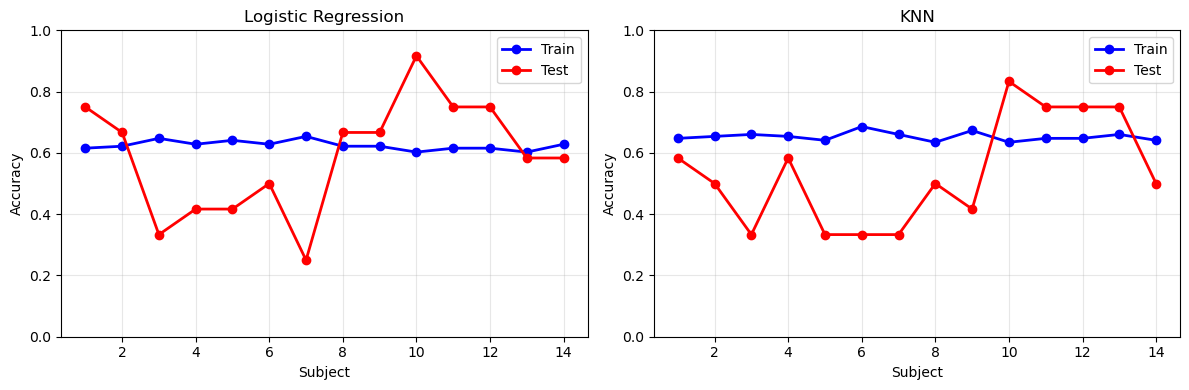

In [15]:
# plot how train and test error changes 

# Plot train vs test
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

subjects = np.arange(1, len(lr_test) + 1)

# Logistic Regression
axes[0].plot(subjects, lr_train, 'o-', label='Train', color='blue', linewidth=2)
axes[0].plot(subjects, lr_test, 'o-', label='Test', color='red', linewidth=2)
axes[0].set_xlabel('Subject')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Logistic Regression')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

# KNN
axes[1].plot(subjects, knn_train, 'o-', label='Train', color='blue', linewidth=2)
axes[1].plot(subjects, knn_test, 'o-', label='Test', color='red', linewidth=2)
axes[1].set_xlabel('Subject')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('KNN')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

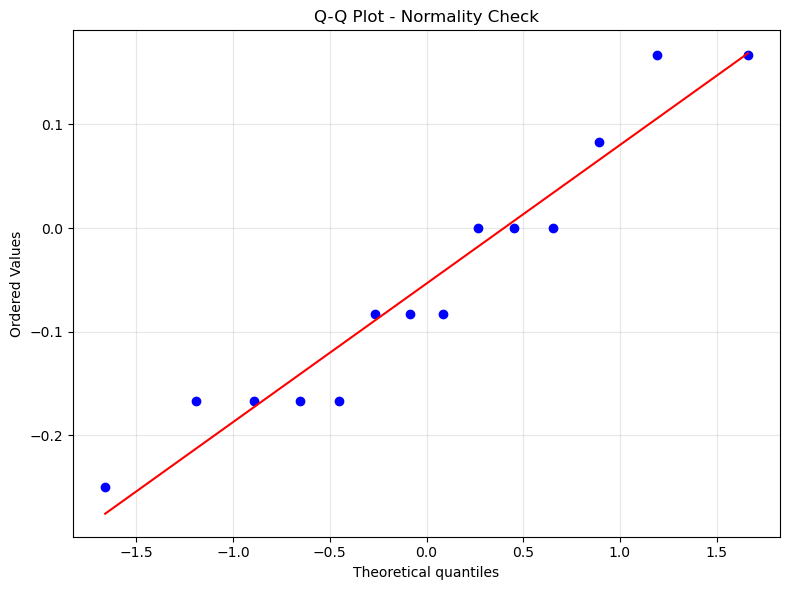

In [16]:
# Normality check
differences = np.array(knn_test) - np.array(lr_test)

plt.figure(figsize=(8, 6))
stats.probplot(differences, dist="norm", plot=plt)
plt.title('Q-Q Plot - Normality Check')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



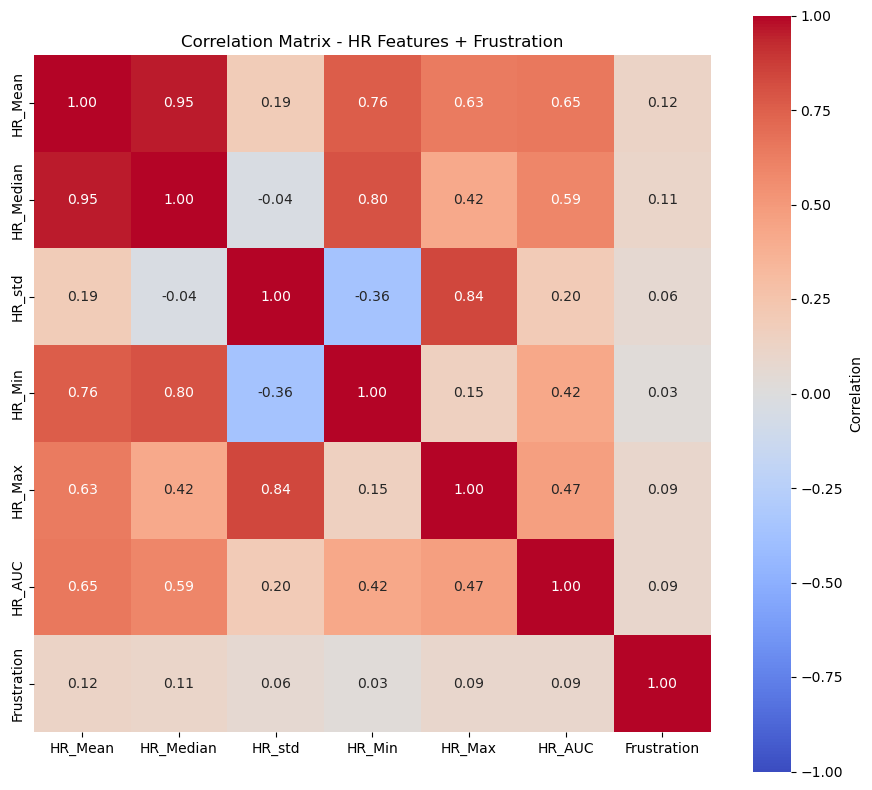

In [17]:
# Correlation matrix: HR features + Frustration
hr_features = ['HR_Mean', 'HR_Median', 'HR_std', 'HR_Min', 'HR_Max', 'HR_AUC']
data_for_corr = df[hr_features + ['Frustrated']].values.astype(float)

# build correlation matrix 
corr_matrix = np.corrcoef(data_for_corr.T)

all_labels = hr_features + ['Frustration']

# plot 
plt.figure(figsize=(9, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=all_labels,
            yticklabels=all_labels,
            center=0, vmin=-1, vmax=1, square=True, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix - HR Features + Frustration')
plt.tight_layout()
plt.show()

In [18]:
# do paired t-test , nomality holds. 


t_stat, p_value = stats.ttest_rel(lr_test, knn_test)
print(f"\nPaired t-test (LR vs KNN on test):")
print(f"  t-statistic: {t_stat:.3f}")
print(f"  p-value: {p_value:.4f}")
if p_value < 0.05:
    print(f"  Result: Significant difference (p < 0.05)")
else:
    print(f"  Result: No significant difference (p >= 0.05)")

mean_diff = np.mean(knn_test) - np.mean(lr_test)
std_diff = np.std(knn_test - np.array(lr_test))
ci = 1.96 * std_diff / np.sqrt(len(lr_test))
print(f"\nMean difference (KNN - LR):")
print(f"  Difference: {mean_diff:.3f}")
print(f"  95% CI: [{mean_diff - ci:.3f}, {mean_diff + ci:.3f}]")


Paired t-test (LR vs KNN on test):
  t-statistic: 1.552
  p-value: 0.1446
  Result: No significant difference (p >= 0.05)

Mean difference (KNN - LR):
  Difference: -0.054
  95% CI: [-0.119, 0.012]


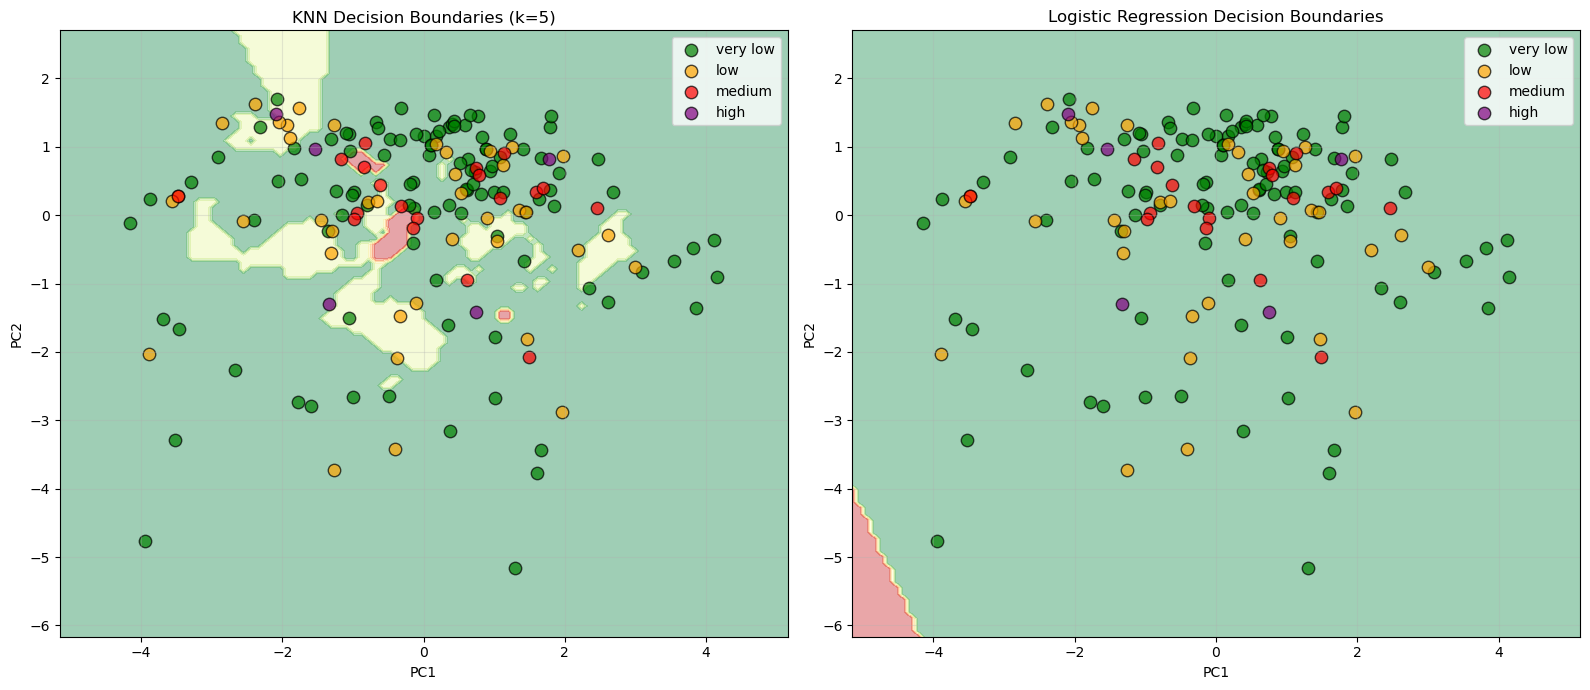

In [ ]:
# Decision boundaries plottet for all data, in reality the bounderies changes for each fold 
k = 5
knn_model = KNeighborsClassifier(n_neighbors=k)
knn_model.fit(X_pca, y)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_pca, y)

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

Z_knn = knn_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z_knn = Z_knn.reshape(xx.shape)

Z_lr = lr_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z_lr = Z_lr.reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors = {0: 'green', 1: 'orange', 2: 'red', 3: "purple", 4: "blue"}
class_names = {0: 'very low', 1: 'low', 2: 'medium', 3: "high", 4: "very high"}

# KNN plot
axes[0].contourf(xx, yy, Z_knn, alpha=0.4, cmap='RdYlGn_r')
for class_val in np.unique(y):
    mask = y == class_val
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=class_names[class_val],
               color=colors[class_val], s=80, alpha=0.7, edgecolors='black')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title(f'KNN Decision Boundaries (k={k})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Logistic Regression plot
axes[1].contourf(xx, yy, Z_lr, alpha=0.4, cmap='RdYlGn_r')
for class_val in np.unique(y):
    mask = y == class_val
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=class_names[class_val],
               color=colors[class_val], s=80, alpha=0.7, edgecolors='black')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Logistic Regression Decision Boundaries')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()